# Week 8 - Evaluation Expansion

Expand the June 2026 holdout evaluation beyond R² by calculating MAPE, MdAPE, MAE, RMSE, prediction coverage thresholds, and signed percentage bias. Results are reported overall and across five actual-price bands for the established Linear Regression, Decision Tree, Random Forest, and CatBoost models.

## Setup

This notebook reuses the Week 6 engineered features and the December 2023 through May 2026 training window. June 2026 remains the untouched test month.

The required libraries were installed in prior weeks. If starting from a new environment:

```bash
python3 -m pip install scikit-learn geopandas pyogrio catboost
```

Feature matrices are converted to `float32`, and the Random Forest and CatBoost models use all available CPU cores for efficient training.

In [1]:
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

DATA_DIR = Path("data")
CLEANED_PATH = DATA_DIR / "week3_cleaned.csv"
RAW_PATHS = sorted(DATA_DIR.glob("CRMLSSold*.csv"))
DISTRICT_PATH = DATA_DIR / "ca_school_district_areas_2024_25.geojson"
DISTRICT_URL = (
    "https://gis.data.ca.gov/api/download/v1/items/"
    "b0e3b936426a47ce9d9a2e77e2bb86cc/geojson?layers=0"
)

if not CLEANED_PATH.exists():
    raise FileNotFoundError("Missing data/week3_cleaned.csv. Run 02_preprocessing.ipynb first.")
if not RAW_PATHS:
    raise FileNotFoundError("Missing raw CRMLS CSV files in data/.")

pd.options.display.float_format = "{:,.4f}".format
RANDOM_STATE = 50
TRAINING_MONTHS = 30
WEEK4_BASELINE_R2 = 0.2999484390

import catboost
from catboost import CatBoostRegressor

def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(y_true)))

print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


## Load modeling and raw property fields

Week 3 stored the model-ready numeric features. `RecordId` is recreated from the unchanged raw-file order so the notebook can recover city, ZIP, coordinates, and the raw fields needed for feature engineering.

In [2]:
cleaned = pd.read_csv(CLEANED_PATH)
week3_metadata_cols = {"RecordId", "CloseDate", "CloseMonth", "ClosePrice", "split"}
week3_feature_cols = [column for column in cleaned.columns if column not in week3_metadata_cols]

RAW_FEATURES = [
    "City", "PostalCode", "Latitude", "Longitude", "YearBuilt",
    "BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "LotSizeSquareFeet",
]


def load_raw_feature_fields(raw_paths):
    frames = []
    start_id = 0

    for path in raw_paths:
        header = pd.read_csv(path, nrows=0).columns
        usecols = [column for column in RAW_FEATURES if column in header]
        frame = pd.read_csv(path, usecols=usecols, low_memory=False)

        for column in RAW_FEATURES:
            if column not in frame:
                frame[column] = pd.NA

        frame["RecordId"] = np.arange(start_id, start_id + len(frame), dtype=np.int64)
        start_id += len(frame)
        frames.append(frame[["RecordId"] + RAW_FEATURES])

    raw = pd.concat(frames, ignore_index=True)
    raw["City_clean"] = (
        raw["City"].astype("string").str.strip().str.upper().replace("", pd.NA)
    )
    raw["PostalCode_clean"] = (
        raw["PostalCode"]
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str[:5]
        .replace("", pd.NA)
    )
    raw["ZIP3"] = raw["PostalCode_clean"].str[:3]
    return raw.drop(columns=["City", "PostalCode"])


raw_fields = load_raw_feature_fields(RAW_PATHS)
df = cleaned.merge(raw_fields, on="RecordId", how="left", validate="one_to_one")

display(df[["RecordId", "CloseMonth", "ClosePrice", "split", "City_clean", "PostalCode_clean"]].head())
display(pd.Series({"rows": len(df), "columns": len(df.columns), "raw_files": len(RAW_PATHS)}).to_frame("value"))

,RecordId,CloseMonth,ClosePrice,split,City_clean,PostalCode_clean
0,279,2022-06,"385,000.0000",train,LITTLEROCK,93543
1,1043,2022-06,"475,000.0000",train,LANCASTER,93534
2,1189,2022-06,"2,350,000.0000",train,TEMPLETON,93465
3,1428,2022-06,"15,880,000.0000",train,RANCHO SANTA FE,92067
4,1763,2022-06,"380,000.0000",train,COACHELLA,92236


,value
rows,406962
columns,55
raw_files,31


## Keep the Week 5 target rules and time split

The target is restricted to at least $50,000 and at most the available training data's 99.5th percentile. The final training window is the 30 months immediately before June 2026.

In [3]:
LOWER_PRICE_BOUND = 50_000
train_target = df.loc[df["split"].eq("train"), "ClosePrice"]
UPPER_PRICE_BOUND = train_target.quantile(0.995)

target_keep_mask = df["ClosePrice"].between(LOWER_PRICE_BOUND, UPPER_PRICE_BOUND)
removed_summary = pd.DataFrame(
    {
        "rows_before": df.groupby("split").size(),
        "rows_removed": df.loc[~target_keep_mask].groupby("split").size(),
    }
).fillna(0).astype(int)
removed_summary["rows_after"] = removed_summary["rows_before"] - removed_summary["rows_removed"]
removed_summary["removed_percent"] = removed_summary["rows_removed"] / removed_summary["rows_before"] * 100

model_df = df.loc[target_keep_mask].copy()
model_df["CloseMonthPeriod"] = pd.PeriodIndex(model_df["CloseMonth"], freq="M")
test_month = model_df.loc[model_df["split"].eq("test"), "CloseMonthPeriod"].max()
train_start_month = test_month - TRAINING_MONTHS

time_keep_mask = (
    (model_df["split"].eq("test") & model_df["CloseMonthPeriod"].eq(test_month))
    | (
        model_df["split"].eq("train")
        & model_df["CloseMonthPeriod"].between(train_start_month, test_month - 1)
    )
)
model_df = model_df.loc[time_keep_mask].drop(columns="CloseMonthPeriod").copy()

split_summary = pd.Series(
    {
        "training_months_used": TRAINING_MONTHS,
        "train_start_month": str(train_start_month),
        "train_end_month": str(test_month - 1),
        "test_month": str(test_month),
        "train_rows": int(model_df["split"].eq("train").sum()),
        "test_rows": int(model_df["split"].eq("test").sum()),
        "lower_price_bound": LOWER_PRICE_BOUND,
        "upper_price_bound": UPPER_PRICE_BOUND,
    }
)
display(removed_summary)
display(split_summary.to_frame("value"))

,rows_before,rows_removed,rows_after,removed_percent
split,,,,
test,12858,84,12774,0.6533
train,394104,2076,392028,0.5268


,value
training_months_used,30
train_start_month,2023-12
train_end_month,2026-05
test_month,2026-06
train_rows,328198
test_rows,12774
lower_price_bound,50000
upper_price_bound,"8,200,000.0000"


## Spatially join school-district boundaries

Invalid or out-of-state coordinates are not joined. California's source combines three district systems, so each property retains separate unified, elementary, and high-school district fields. This avoids losing information where elementary and high-school areas overlap.

In [4]:
if not DISTRICT_PATH.exists():
    print("Downloading official California school-district boundaries...")
    urlretrieve(DISTRICT_URL, DISTRICT_PATH)

district_columns = [
    "CDCode", "DistrictName", "DistrictType", "EnrollTotal",
    "SEDpct", "DistrctAreaSqMi", "geometry",
]
districts = gpd.read_file(DISTRICT_PATH)[district_columns].to_crs("EPSG:4326")


def add_school_district_fields(frame, boundaries):
    latitude = pd.to_numeric(frame["Latitude"], errors="coerce")
    longitude = pd.to_numeric(frame["Longitude"], errors="coerce")
    valid_coordinates = latitude.between(32.0, 42.5) & longitude.between(-125.0, -114.0)

    points = gpd.GeoDataFrame(
        frame.loc[valid_coordinates, ["RecordId"]].copy(),
        geometry=gpd.points_from_xy(
            longitude.loc[valid_coordinates], latitude.loc[valid_coordinates]
        ),
        crs="EPSG:4326",
    )
    enriched = frame.copy()

    for district_type in ["Unified", "Elementary", "High"]:
        prefix = district_type.lower()
        layer = boundaries.loc[
            boundaries["DistrictType"].eq(district_type),
            ["CDCode", "DistrictName", "EnrollTotal", "SEDpct", "DistrctAreaSqMi", "geometry"],
        ]
        joined = gpd.sjoin(points, layer, how="left", predicate="within")
        joined = (
            joined.sort_values(["RecordId", "CDCode"], na_position="last")
            .drop_duplicates("RecordId")
            .drop(columns=["geometry", "index_right"])
            .rename(
                columns={
                    "CDCode": f"{prefix}_district_code",
                    "DistrictName": f"{prefix}_district_name",
                    "EnrollTotal": f"{prefix}_district_enrollment",
                    "SEDpct": f"{prefix}_district_sed_pct",
                    "DistrctAreaSqMi": f"{prefix}_district_area_sqmi",
                }
            )
        )
        enriched = enriched.merge(joined, on="RecordId", how="left", validate="one_to_one")

    enriched["valid_coordinate"] = enriched["RecordId"].isin(points["RecordId"]).astype("int8")
    district_code_cols = [
        "unified_district_code", "elementary_district_code", "high_district_code"
    ]
    enriched["school_district_match_count"] = enriched[district_code_cols].notna().sum(axis=1)
    enriched["school_district_any_match"] = enriched["school_district_match_count"].gt(0).astype("int8")
    return enriched


join_start = perf_counter()
model_df = add_school_district_fields(model_df, districts)
join_seconds = perf_counter() - join_start

district_coverage = pd.DataFrame(
    {
        "matched_rows": {
            "valid coordinates": model_df["valid_coordinate"].sum(),
            "any district": model_df["school_district_any_match"].sum(),
            "unified": model_df["unified_district_code"].notna().sum(),
            "elementary": model_df["elementary_district_code"].notna().sum(),
            "high": model_df["high_district_code"].notna().sum(),
        }
    }
)
district_coverage["percent_of_model_rows"] = district_coverage["matched_rows"] / len(model_df) * 100
display(district_coverage)
print(f"Spatial join completed in {join_seconds:.1f} seconds.")

,matched_rows,percent_of_model_rows
valid coordinates,340779,99.9434
any district,340742,99.9325
unified,255521,74.9390
elementary,86706,25.4291
high,85003,24.9296


Spatial join completed in 2.3 seconds.


## Engineer property and categorical geography features

Property age is measured at the close date. Ratios use raw values, with invalid denominators treated as missing. Every engineered numeric feature is clipped and imputed from the training partition only. The existing city and ZIP identifiers keep their Week 5 smoothed log-price encoding: leave-one-out values for training rows and training-only aggregates for test rows.

In [5]:
train = model_df[model_df["split"].eq("train")].copy()
test = model_df[model_df["split"].eq("test")].copy()


def add_smoothed_log_target_encoding(train, test, column, smoothing=50):
    encoded_name = f"{column}_log_price_te"
    count_name = f"{column}_count_log"

    train_key = train[column].fillna("__MISSING__").astype("string")
    test_key = test[column].fillna("__MISSING__").astype("string")
    train_log_target = np.log1p(train["ClosePrice"])
    global_mean = train_log_target.mean()

    stats = (
        pd.DataFrame({column: train_key, "log_target": train_log_target})
        .groupby(column)["log_target"]
        .agg(["count", "sum"])
    )
    train_count = train_key.map(stats["count"]).astype(float)
    train_sum = train_key.map(stats["sum"]).astype(float)
    loo_count = train_count - 1
    loo_sum = train_sum - train_log_target.to_numpy()

    train[encoded_name] = np.where(
        loo_count > 0,
        (loo_sum + smoothing * global_mean) / (loo_count + smoothing),
        global_mean,
    )
    smoothed_test_map = (stats["sum"] + smoothing * global_mean) / (stats["count"] + smoothing)
    train[count_name] = np.log1p(train_count)
    test[encoded_name] = test_key.map(smoothed_test_map).fillna(global_mean)
    test[count_name] = np.log1p(test_key.map(stats["count"]).fillna(0).astype(float))
    return train, test, [encoded_name, count_name]


location_feature_cols = []
for location_column in ["City_clean", "PostalCode_clean", "ZIP3"]:
    train, test, added = add_smoothed_log_target_encoding(
        train, test, location_column, smoothing=50
    )
    location_feature_cols.extend(added)


def add_train_clipped_feature(train, test, output_name, train_values, test_values):
    train_values = pd.Series(train_values, index=train.index).replace([np.inf, -np.inf], np.nan)
    test_values = pd.Series(test_values, index=test.index).replace([np.inf, -np.inf], np.nan)
    lower, upper = train_values.quantile([0.005, 0.995])
    median = train_values.clip(lower, upper).median()

    missing_name = f"{output_name}_missing"
    train[missing_name] = train_values.isna().astype("int8")
    test[missing_name] = test_values.isna().astype("int8")
    train[output_name] = train_values.clip(lower, upper).fillna(median)
    test[output_name] = test_values.clip(lower, upper).fillna(median)
    return train, test, [output_name, missing_name]


train_close_year = pd.to_datetime(train["CloseDate"]).dt.year
test_close_year = pd.to_datetime(test["CloseDate"]).dt.year

train_age = train_close_year - pd.to_numeric(train["YearBuilt"], errors="coerce")
test_age = test_close_year - pd.to_numeric(test["YearBuilt"], errors="coerce")
train_age = train_age.where(train_age.between(0, 250))
test_age = test_age.where(test_age.between(0, 250))

train_baths = pd.to_numeric(train["BathroomsTotalInteger"], errors="coerce")
test_baths = pd.to_numeric(test["BathroomsTotalInteger"], errors="coerce")
train_beds = pd.to_numeric(train["BedroomsTotal"], errors="coerce")
test_beds = pd.to_numeric(test["BedroomsTotal"], errors="coerce")
train_living = pd.to_numeric(train["LivingArea"], errors="coerce")
test_living = pd.to_numeric(test["LivingArea"], errors="coerce")
train_lot = pd.to_numeric(train["LotSizeSquareFeet"], errors="coerce")
test_lot = pd.to_numeric(test["LotSizeSquareFeet"], errors="coerce")

property_specs = {
    "PropertyAgeYears": (train_age, test_age),
    "BedBathRatio": (train_beds.div(train_baths.where(train_baths.gt(0))), test_beds.div(test_baths.where(test_baths.gt(0)))),
    "LivingAreaPerBedroom": (train_living.div(train_beds.where(train_beds.gt(0))), test_living.div(test_beds.where(test_beds.gt(0)))),
    "LivingAreaPerBathroom": (train_living.div(train_baths.where(train_baths.gt(0))), test_living.div(test_baths.where(test_baths.gt(0)))),
    "LotUtilizationRatio": (train_living.div(train_lot.where(train_lot.gt(0))), test_living.div(test_lot.where(test_lot.gt(0)))),
}

property_feature_cols = []
for output_name, (train_values, test_values) in property_specs.items():
    train, test, added = add_train_clipped_feature(
        train, test, output_name, train_values, test_values
    )
    property_feature_cols.extend(added)

display(train[property_feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
PropertyAgeYears,"328,198.0000",49.0992,27.3288,0.0000,27.0000,49.0000,69.0000,119.0000
PropertyAgeYears_missing,"328,198.0000",0.0007,0.0265,0.0000,0.0000,0.0000,0.0000,1.0000
BedBathRatio,"328,198.0000",1.4628,0.4689,0.6667,1.0000,1.5000,1.5000,3.0000
BedBathRatio_missing,"328,198.0000",0.0005,0.0234,0.0000,0.0000,0.0000,0.0000,1.0000
LivingAreaPerBedroom,"328,198.0000",573.8840,182.2226,284.0000,445.0000,538.5000,660.6667,"1,325.8837"
LivingAreaPerBedroom_missing,"328,198.0000",0.0009,0.0304,0.0000,0.0000,0.0000,0.0000,1.0000
LivingAreaPerBathroom,"328,198.0000",788.1538,192.1281,399.0000,649.0000,766.6667,900.6667,"1,465.0000"
LivingAreaPerBathroom_missing,"328,198.0000",0.0010,0.0308,0.0000,0.0000,0.0000,0.0000,1.0000
LotUtilizationRatio,"328,198.0000",0.2692,0.1737,0.0034,0.1680,0.2357,0.3301,1.1888
LotUtilizationRatio_missing,"328,198.0000",0.0180,0.1331,0.0000,0.0000,0.0000,0.0000,1.0000


## Encode the school-district layer

Public boundary attributes add district enrollment, socioeconomic-disadvantage percentage, and district area separately for unified, elementary, and high-school systems. Missing flags distinguish unified-only areas from elementary/high overlaps and unmatched coordinates. District codes and names remain available for audit, but are not target encoded: an ablation check found that their historical price averages were too brittle for the tree-model holdout.

In [6]:
district_numeric_feature_cols = [
    "valid_coordinate", "school_district_match_count", "school_district_any_match"
]

for prefix in ["unified", "elementary", "high"]:
    numeric_specs = {
        f"{prefix}_district_enrollment_log": (
            np.log1p(pd.to_numeric(train[f"{prefix}_district_enrollment"], errors="coerce")),
            np.log1p(pd.to_numeric(test[f"{prefix}_district_enrollment"], errors="coerce")),
        ),
        f"{prefix}_district_sed_share": (
            pd.to_numeric(train[f"{prefix}_district_sed_pct"], errors="coerce") / 100,
            pd.to_numeric(test[f"{prefix}_district_sed_pct"], errors="coerce") / 100,
        ),
        f"{prefix}_district_area_log": (
            np.log1p(pd.to_numeric(train[f"{prefix}_district_area_sqmi"], errors="coerce")),
            np.log1p(pd.to_numeric(test[f"{prefix}_district_area_sqmi"], errors="coerce")),
        ),
    }
    for output_name, (train_values, test_values) in numeric_specs.items():
        train, test, added = add_train_clipped_feature(
            train, test, output_name, train_values, test_values
        )
        district_numeric_feature_cols.extend(added)

district_feature_cols = district_numeric_feature_cols
display(pd.Series({
    "property_features_added": len(property_feature_cols),
    "district_features_added": len(district_feature_cols),
    "district_numeric_features": len(district_numeric_feature_cols),
}).to_frame("count"))

,count
property_features_added,10
district_features_added,21
district_numeric_features,21


## Define old and new feature sets

`Old (Week 5)` recreates the prior model matrix. `New (Week 6)` adds only the engineered property and school-district features, keeping every row, split rule, target rule, and model setting fixed.

In [7]:
old_feature_cols = week3_feature_cols + location_feature_cols
new_feature_cols = old_feature_cols + property_feature_cols + district_feature_cols

# Final guardrail: use training-only medians for any values still missing after
# the feature-specific transforms (and zero only if a column is entirely missing).
all_model_feature_cols = list(dict.fromkeys(new_feature_cols))
remaining_missing_before_fill = pd.DataFrame({
    "train_missing": train[all_model_feature_cols].isna().sum(),
    "test_missing": test[all_model_feature_cols].isna().sum(),
})
remaining_missing_before_fill = remaining_missing_before_fill.loc[
    remaining_missing_before_fill.sum(axis=1).gt(0)
]
final_train_medians = train[all_model_feature_cols].median(numeric_only=True)
train[all_model_feature_cols] = (
    train[all_model_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(final_train_medians)
    .fillna(0)
)
test[all_model_feature_cols] = (
    test[all_model_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(final_train_medians)
    .fillna(0)
)

if not remaining_missing_before_fill.empty:
    display(remaining_missing_before_fill)

feature_sets = {
    "Old (Week 5)": old_feature_cols,
    "New (Week 6 + school districts)": new_feature_cols,
}
y_train = train["ClosePrice"]
y_test = test["ClosePrice"]

matrix_summary = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "train_rows": len(train),
            "test_rows": len(test),
            "feature_count": len(columns),
            "missing_train_values": int(train[columns].isna().sum().sum()),
            "missing_test_values": int(test[columns].isna().sum().sum()),
        }
        for feature_set_name, columns in feature_sets.items()
    ]
)
display(matrix_summary)

assert matrix_summary[["missing_train_values", "missing_test_values"]].to_numpy().sum() == 0

,feature_set,train_rows,test_rows,feature_count,missing_train_values,missing_test_values
0,Old (Week 5),328198,12774,46,0,0
1,New (Week 6 + school districts),328198,12774,77,0,0


## Train the established models

All models use the same 77-feature Week 6 matrix, identical target filtering, and the same June 2026 observations. This keeps the expanded metrics directly comparable.

In [8]:
X_train = train[new_feature_cols].astype("float32")
y_train = train["ClosePrice"].astype("float32")
X_test = test[new_feature_cols].astype("float32")
y_test = test["ClosePrice"].astype("float32")

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=22,
        min_samples_leaf=25,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=60,
        max_depth=22,
        min_samples_leaf=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=540,
        depth=4,
        learning_rate=0.05,
        loss_function="RMSE",
        eval_metric="RMSE",
        subsample=0.85,
        bootstrap_type="Bernoulli",
        l2_leaf_reg=5.0,
        random_strength=1.0,
        thread_count=-1,
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
    ),
}

predictions = {}
fit_times = {}

for model_name, model in models.items():
    start = perf_counter()
    model.fit(X_train, y_train)
    fit_times[model_name] = perf_counter() - start
    predictions[model_name] = model.predict(X_test)

training_summary = pd.DataFrame(
    {
        "model": list(models),
        "fit_seconds": [fit_times[name] for name in models],
        "train_rows": len(train),
        "test_rows": len(test),
        "features": len(new_feature_cols),
        "test_month": test["CloseMonth"].unique()[0],
    }
)
display(training_summary.style.format({"fit_seconds": "{:.1f}"}))

,model,fit_seconds,train_rows,test_rows,features,test_month
0,Linear Regression,0.6,328198,12774,77,2026-06
1,Decision Tree,9.6,328198,12774,77,2026-06
2,Random Forest,12.8,328198,12774,77,2026-06
3,CatBoost,9.9,328198,12774,77,2026-06


## Metric definitions

- **MAPE:** mean absolute percentage error; summarizes the average relative miss but is sensitive to unusually large percentage errors.
- **MdAPE:** median absolute percentage error; represents the typical relative miss and is more robust to extreme errors.
- **Within 10% / 20%:** share of predictions whose absolute percentage error falls within the stated threshold.
- **Mean signed percentage error:** directional bias. Positive means predictions are high on average; negative means predictions are low.

Because the modeling target is restricted to prices of at least $50,000, the percentage-error denominator is always positive and safely away from zero.

In [9]:
def expanded_metrics(y_true, y_pred):
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)
    signed_percentage_error = (y_pred_array - y_true_array) / y_true_array
    absolute_percentage_error = np.abs(signed_percentage_error)

    return {
        "r2": r2_score(y_true_array, y_pred_array),
        "mae": mean_absolute_error(y_true_array, y_pred_array),
        "rmse": root_mean_squared_error(y_true_array, y_pred_array),
        "mape": absolute_percentage_error.mean(),
        "mdape": np.median(absolute_percentage_error),
        "within_10_pct": np.mean(absolute_percentage_error <= 0.10),
        "within_20_pct": np.mean(absolute_percentage_error <= 0.20),
        "mean_signed_pct_error": signed_percentage_error.mean(),
    }


overall_rows = []
for model_name, y_pred in predictions.items():
    overall_rows.append(
        {
            "scope": "overall",
            "price_band": "All prices",
            "model": model_name,
            "row_count": len(y_test),
            **expanded_metrics(y_test, y_pred),
        }
    )

overall_metrics = (
    pd.DataFrame(overall_rows)
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
)
display(overall_metrics.style.format({
    "r2": "{:.4f}",
    "mae": "${:,.0f}",
    "rmse": "${:,.0f}",
    "mape": "{:.2%}",
    "mdape": "{:.2%}",
    "within_10_pct": "{:.2%}",
    "within_20_pct": "{:.2%}",
    "mean_signed_pct_error": "{:+.2%}",
}))

,scope,price_band,model,row_count,r2,mae,rmse,mape,mdape,within_10_pct,within_20_pct,mean_signed_pct_error
0,overall,All prices,Random Forest,12774,0.8540,"$186,746","$375,531",14.83%,9.68%,51.10%,76.34%,+4.58%
1,overall,All prices,CatBoost,12774,0.8493,"$192,516","$381,457",14.97%,10.26%,49.11%,76.87%,+2.62%
2,overall,All prices,Linear Regression,12774,0.7434,"$300,841","$497,769",31.20%,19.67%,28.33%,50.65%,+0.77%
3,overall,All prices,Decision Tree,12774,0.7412,"$260,193","$499,956",19.90%,14.61%,36.56%,63.33%,+3.04%


## Performance by actual-price band

Fixed dollar bands make business interpretation easier and remain stable across future reruns. Percentage metrics are emphasized for band comparisons because within-band R² can be unstable when the actual-price range is narrow.

In [10]:
PRICE_BAND_EDGES = [50_000, 500_000, 1_000_000, 2_000_000, 5_000_000, np.inf]
PRICE_BAND_LABELS = [
    "$50K-$500K",
    "$500K-$1M",
    "$1M-$2M",
    "$2M-$5M",
    "$5M+",
]

test_evaluation = pd.DataFrame(
    {
        "actual": y_test.to_numpy(dtype=float),
        "price_band": pd.cut(
            y_test.to_numpy(dtype=float),
            bins=PRICE_BAND_EDGES,
            labels=PRICE_BAND_LABELS,
            include_lowest=True,
            right=False,
        ),
    },
    index=test.index,
)

band_rows = []
for model_name, y_pred in predictions.items():
    model_evaluation = test_evaluation.copy()
    model_evaluation["prediction"] = y_pred

    for price_band in PRICE_BAND_LABELS:
        band = model_evaluation.loc[model_evaluation["price_band"].eq(price_band)]
        band_rows.append(
            {
                "scope": "price_band",
                "price_band": price_band,
                "model": model_name,
                "row_count": len(band),
                **expanded_metrics(band["actual"], band["prediction"]),
            }
        )

band_metrics = pd.DataFrame(band_rows)
band_metrics["price_band"] = pd.Categorical(
    band_metrics["price_band"],
    categories=PRICE_BAND_LABELS,
    ordered=True,
)
band_metrics = band_metrics.sort_values(["price_band", "mdape", "model"]).reset_index(drop=True)

display(band_metrics.style.format({
    "r2": "{:.4f}",
    "mae": "${:,.0f}",
    "rmse": "${:,.0f}",
    "mape": "{:.2%}",
    "mdape": "{:.2%}",
    "within_10_pct": "{:.2%}",
    "within_20_pct": "{:.2%}",
    "mean_signed_pct_error": "{:+.2%}",
}))

,scope,price_band,model,row_count,r2,mae,rmse,mape,mdape,within_10_pct,within_20_pct,mean_signed_pct_error
0,price_band,$50K-$500K,CatBoost,1760,-0.5796,"$71,081","$108,352",22.58%,11.41%,45.57%,69.55%,+15.51%
1,price_band,$50K-$500K,Random Forest,1760,-0.7900,"$78,318","$115,343",25.58%,13.24%,41.59%,63.12%,+23.92%
2,price_band,$50K-$500K,Decision Tree,1760,-1.4124,"$95,502","$133,902",29.78%,17.99%,30.63%,54.20%,+26.27%
3,price_band,$50K-$500K,Linear Regression,1760,-13.6465,"$270,874","$329,935",79.55%,64.84%,7.95%,16.25%,-36.90%
4,price_band,$500K-$1M,Random Forest,5312,0.1269,"$89,411","$130,671",12.24%,7.85%,58.81%,81.01%,+7.30%
5,price_band,$500K-$1M,CatBoost,5312,0.0891,"$91,027","$133,464",12.38%,8.74%,56.02%,82.91%,+4.37%
6,price_band,$500K-$1M,Decision Tree,5312,-0.6201,"$124,809","$177,996",16.88%,11.98%,42.94%,70.39%,+7.52%
7,price_band,$500K-$1M,Linear Regression,5312,-2.8909,"$197,311","$275,842",27.41%,20.04%,27.65%,49.92%,+8.33%
8,price_band,$1M-$2M,Random Forest,3987,0.2244,"$168,294","$237,391",12.02%,9.18%,53.25%,82.79%,+0.23%
9,price_band,$1M-$2M,CatBoost,3987,0.0012,"$192,045","$269,388",13.68%,10.56%,47.91%,78.20%,+0.52%


## Export metrics summary

In [11]:
model_order = list(models)
price_band_order = ["All prices"] + PRICE_BAND_LABELS

metrics_summary = pd.concat([overall_metrics, band_metrics], ignore_index=True)
metrics_summary["model"] = pd.Categorical(
    metrics_summary["model"], categories=model_order, ordered=True
)
metrics_summary["price_band"] = pd.Categorical(
    metrics_summary["price_band"], categories=price_band_order, ordered=True
)
metrics_summary = (
    metrics_summary
    .sort_values(["scope", "price_band", "model"])
    .reset_index(drop=True)
)
metrics_summary["model"] = metrics_summary["model"].astype("string")
metrics_summary["price_band"] = metrics_summary["price_band"].astype("string")

METRICS_OUTPUT_PATH = Path("metrics_summary.csv")
metrics_summary.to_csv(METRICS_OUTPUT_PATH, index=False, float_format="%.6f")

print(f"Wrote {len(metrics_summary)} rows to {METRICS_OUTPUT_PATH}")
display(metrics_summary.head(10))

Wrote 24 rows to metrics_summary.csv


,scope,price_band,model,row_count,r2,mae,rmse,mape,mdape,within_10_pct,within_20_pct,mean_signed_pct_error
0,overall,All prices,Linear Regression,12774,0.7434,"300,841.3520","497,769.0282",0.3120,0.1967,0.2833,0.5065,0.0077
1,overall,All prices,Decision Tree,12774,0.7412,"260,192.6956","499,956.2133",0.1990,0.1461,0.3656,0.6333,0.0304
2,overall,All prices,Random Forest,12774,0.8540,"186,746.4948","375,530.6768",0.1483,0.0968,0.5110,0.7634,0.0458
3,overall,All prices,CatBoost,12774,0.8493,"192,516.3020","381,456.6108",0.1497,0.1026,0.4911,0.7687,0.0262
4,price_band,$50K-$500K,Linear Regression,1760,-13.6465,"270,873.9400","329,935.3097",0.7955,0.6484,0.0795,0.1625,-0.3690
5,price_band,$50K-$500K,Decision Tree,1760,-1.4124,"95,501.7040","133,901.7540",0.2978,0.1799,0.3063,0.5420,0.2627
6,price_band,$50K-$500K,Random Forest,1760,-0.7900,"78,317.7640","115,342.6804",0.2558,0.1324,0.4159,0.6312,0.2392
7,price_band,$50K-$500K,CatBoost,1760,-0.5796,"71,080.5033","108,351.5193",0.2258,0.1141,0.4557,0.6955,0.1551
8,price_band,$500K-$1M,Linear Regression,5312,-2.8909,"197,311.4846","275,841.5470",0.2741,0.2004,0.2765,0.4992,0.0833
9,price_band,$500K-$1M,Decision Tree,5312,-0.6201,"124,808.8034","177,996.1147",0.1688,0.1198,0.4294,0.7039,0.0752


## Price-band insights

,insight,finding,value
0,Best overall model,Random Forest,R² 0.8540; MdAPE 9.68%
1,Best-performing price band,$500K-$1M,"MdAPE 7.85%; 5,312 rows"
2,Most difficult price band,$5M+,MdAPE 27.72%; 175 rows
3,Direction of bias in difficult band,Underprediction,Mean signed error -29.21%


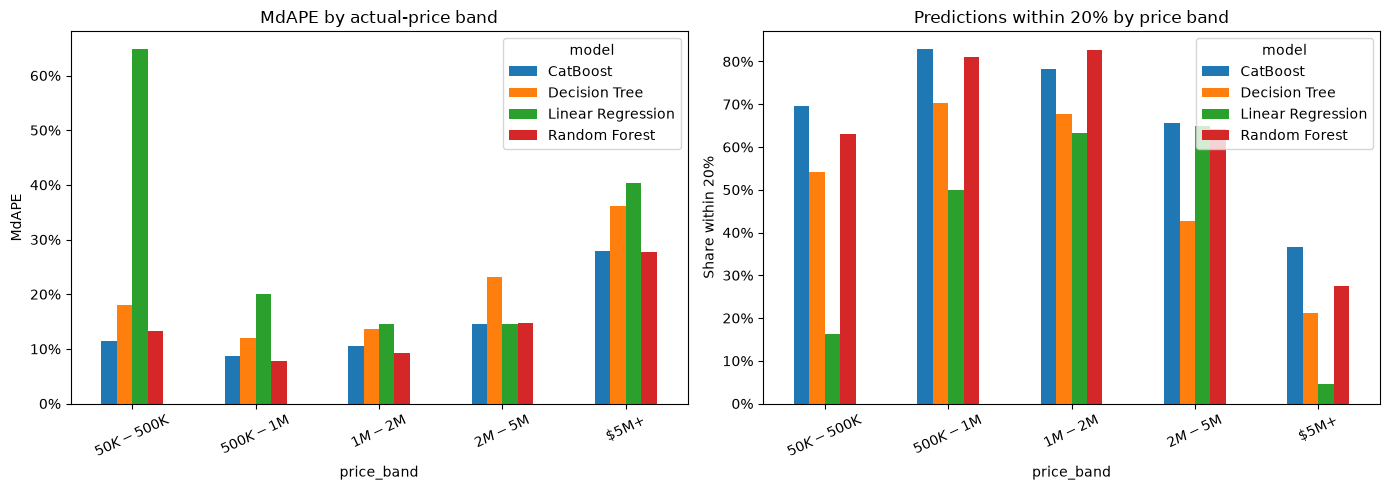

In [12]:
best_overall_model = overall_metrics.iloc[0]["model"]
best_model_bands = (
    band_metrics.loc[band_metrics["model"].eq(best_overall_model)]
    .sort_values("mdape")
    .reset_index(drop=True)
)
strongest_band = best_model_bands.iloc[0]
weakest_band = best_model_bands.iloc[-1]

insight_summary = pd.DataFrame(
    [
        {
            "insight": "Best overall model",
            "finding": best_overall_model,
            "value": f"R² {overall_metrics.iloc[0]['r2']:.4f}; MdAPE {overall_metrics.iloc[0]['mdape']:.2%}",
        },
        {
            "insight": "Best-performing price band",
            "finding": str(strongest_band["price_band"]),
            "value": f"MdAPE {strongest_band['mdape']:.2%}; {int(strongest_band['row_count']):,} rows",
        },
        {
            "insight": "Most difficult price band",
            "finding": str(weakest_band["price_band"]),
            "value": f"MdAPE {weakest_band['mdape']:.2%}; {int(weakest_band['row_count']):,} rows",
        },
        {
            "insight": "Direction of bias in difficult band",
            "finding": "Overprediction" if weakest_band["mean_signed_pct_error"] > 0 else "Underprediction",
            "value": f"Mean signed error {weakest_band['mean_signed_pct_error']:+.2%}",
        },
    ]
)
display(insight_summary)

band_mdape_pivot = band_metrics.pivot(
    index="price_band", columns="model", values="mdape"
).reindex(PRICE_BAND_LABELS)
band_coverage_pivot = band_metrics.pivot(
    index="price_band", columns="model", values="within_20_pct"
).reindex(PRICE_BAND_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
band_mdape_pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("MdAPE by actual-price band")
axes[0].set_ylabel("MdAPE")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[0].tick_params(axis="x", rotation=25)

band_coverage_pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Predictions within 20% by price band")
axes[1].set_ylabel("Share within 20%")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()

## Evaluation notes

- MAPE is useful for average relative error but can be pulled upward by a smaller number of severe misses; MdAPE better reflects a typical transaction.
- Dollar metrics naturally rise with price, so cross-band comparisons should emphasize MAPE, MdAPE, and threshold coverage.
- The highest-price band has fewer observations than the central market bands, so its metrics are more sensitive to individual luxury-property errors.
- A model can have strong overall R² while still showing meaningful percentage bias within a specific market segment; both views should be monitored.

## Week 8 outcome

Random Forest is the best overall model with R² = 0.8540, MAPE = 14.83%, and MdAPE = 9.68%. Its strongest segment is $500K-$1M (MdAPE 7.85%), while $5M+ is the most difficult (MdAPE 27.72%) and averages 29.21% underprediction across only 175 sales. CatBoost is strongest for $50K-$500K by MdAPE, showing that model performance varies by segment even when Random Forest leads overall. `metrics_summary.csv` provides all overall and price-band results in a reusable format.